In [44]:
import pandas as pd
import matplotlib.pyplot as plt
import sqlite3

plt.rcParams['savefig.dpi'] = 300

## opens sqlite database
conn = sqlite3.connect("./data/game.db")

def statement_to_df(s: str):
    cursor = conn.cursor()
    cursor.execute(s)
    conn.commit()
    cols = [description[0] for description in cursor.description]
    list = cursor.fetchall()
    df = pd.DataFrame(list, columns=cols)
    return df

def get_tables():
    cursor = conn.cursor()
    cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
    tables = cursor.fetchall()
    return [table[0] for table in tables]

    

def plot_statement(s: str):
    df = statement_to_df(s)
    ## now plot
    plt.plot(df)
    plt.show()

In [45]:
experiments_info = statement_to_df(f"""
                select id, number_of_servers, number_of_bots, number_of_servers * number_of_bots as total_bots from experiments
                """)
experiments_info.set_index('id', inplace=True)

In [ ]:
import numpy as np
import scipy.stats as stats
df = statement_to_df(f"""
                select tick as x, micros_elapsed / 1000.0 as y, et.experiment_id
                from experiment_ticks et
                where et.tick > 200 and et.tick < 1400
                """)

grouped = df.groupby('experiment_id')


confidence = 0.95

# Group by experiment and calculate stats
stats_df = df.groupby('experiment_id')['y'].agg(['mean', 'sem', 'count', 'var', 'std', 'min', 'max'])
stats_df['ci'] = stats_df.apply(
    lambda row: stats.t.ppf(0.975, row['count']-1) * row['sem'], 
    axis=1
)

# Merge the data
merged_df = stats_df.merge(experiments_info, left_index=True, right_on='id')


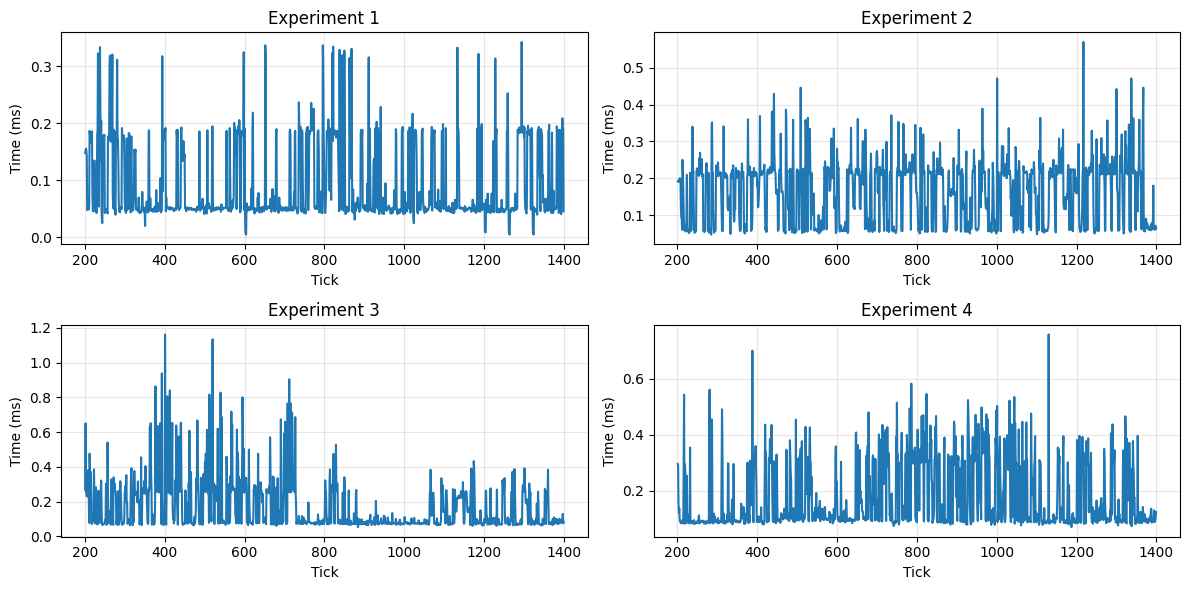

In [47]:
n_experiments = 4

# Calculate grid dimensions (e.g., 3 columns)
n_cols = 2
n_rows = int(np.ceil(n_experiments / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, n_rows*3))
axes = axes.flatten()  # Flatten to 1D array for easy indexing

for i, (experiment_id, group) in enumerate(grouped):
    if i >= n_experiments:
        break
    axes[i].plot(group['x'], group['y'])
    axes[i].set_title(f'Experiment {experiment_id}')
    axes[i].set_xlabel('Tick')
    axes[i].set_ylabel('Time (ms)')
    axes[i].grid(True, alpha=0.3)

# Hide unused subplots
for j in range(i+1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.savefig('./assets/experiment_ticks.jpg')
plt.show()

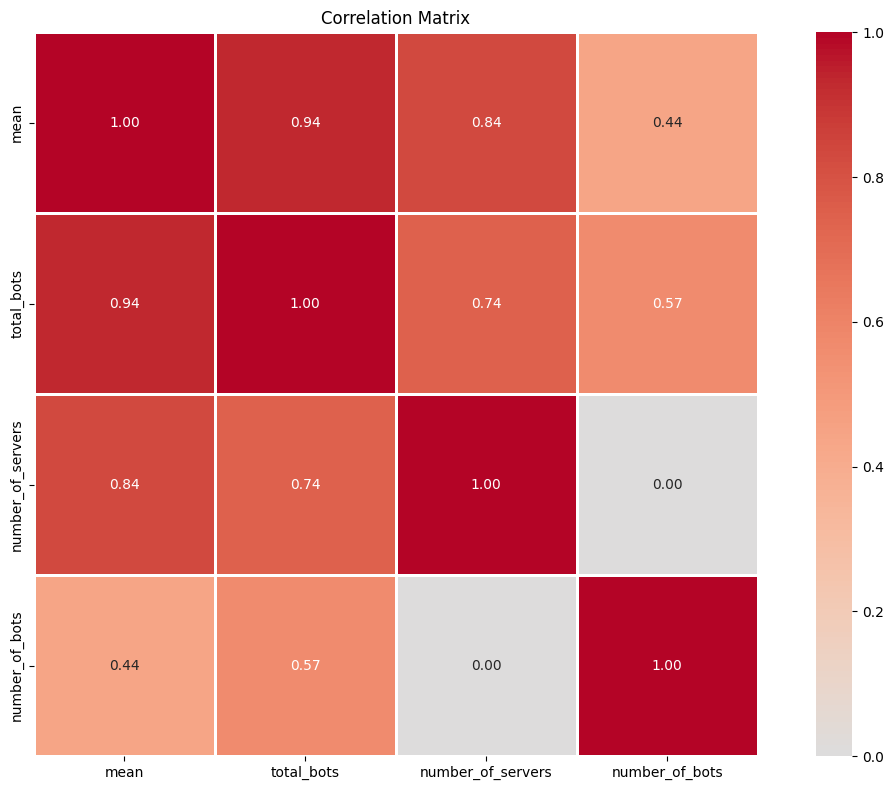

In [48]:
import seaborn as sns

# Calculate correlation matrix
corr = merged_df[['mean', 'total_bots', 'number_of_servers', 'number_of_bots']].corr()

# Plot heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, 
            fmt='.2f', square=True, linewidths=1)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.savefig('./assets/correlation_matrix.jpg')
plt.show()

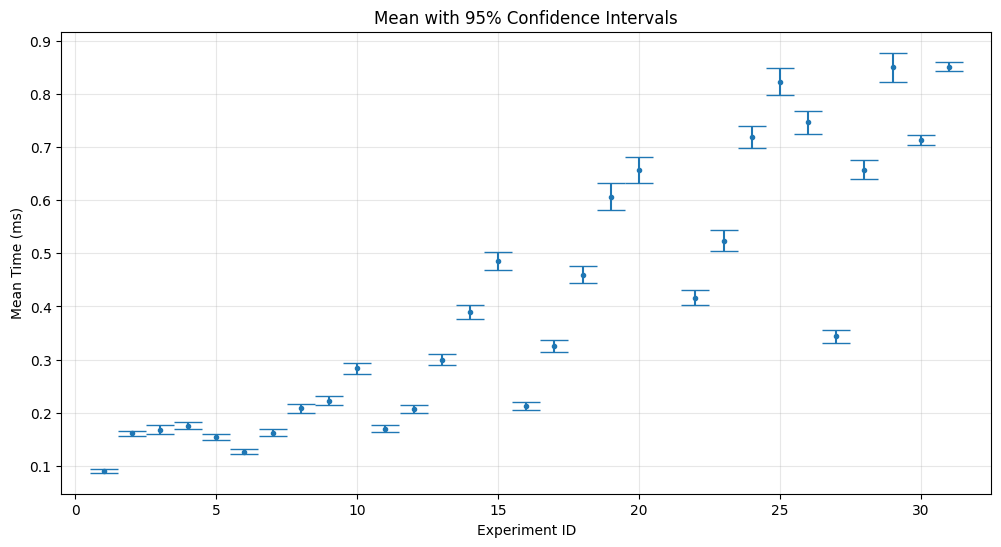

In [49]:
plt.figure(figsize=(12, 6))
plt.errorbar(stats_df.index, stats_df['mean'], yerr=stats_df['ci'], 
             fmt='o', capsize=10, capthick=1, markersize=3)
plt.xlabel('Experiment ID')
plt.ylabel('Mean Time (ms)')
plt.title('Mean with 95% Confidence Intervals')
plt.grid(True, alpha=0.3)
plt.savefig('./assets/experiment_mean_ci.jpg')
plt.show()

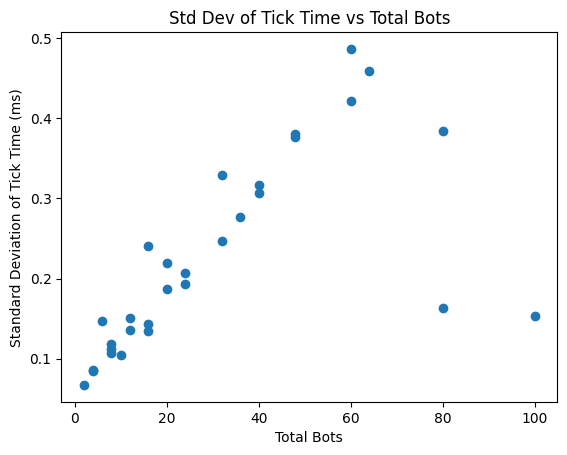

In [50]:
plt.scatter(merged_df['total_bots'], merged_df['std'])
plt.xlabel('Total Bots')
plt.ylabel('Standard Deviation of Tick Time (ms)')
plt.title('Std Dev of Tick Time vs Total Bots')
plt.savefig('./assets/experiment_std_vs_bots.jpg')
plt.show()

Text(0.5, 1.0, 'Mean Time vs Total Bots with Linear Regression R²: 0.88')

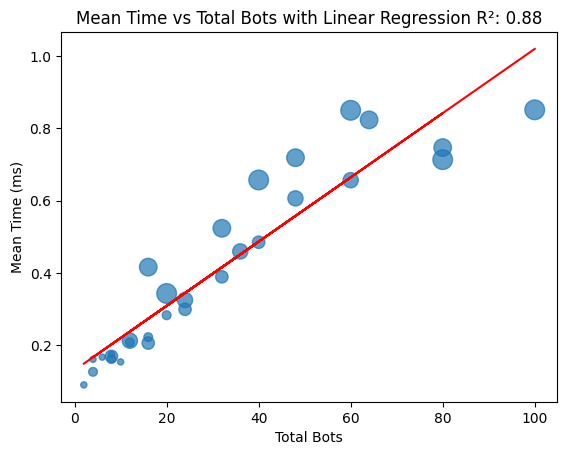

In [51]:
from sklearn.linear_model import LinearRegression


model = LinearRegression()
X = merged_df[['total_bots']]
y = merged_df['mean']
model.fit(X, y)
r2 = model.score(X, y)
sizes = merged_df['number_of_servers']
plt.scatter(merged_df['total_bots'], merged_df['mean'], s=sizes*20, alpha=0.7)
plt.plot(merged_df['total_bots'], model.predict(X), color='red')
plt.xlabel('Total Bots')
plt.ylabel('Mean Time (ms)')
plt.savefig('./assets/mean_time_vs_total_bots.jpg')
plt.title(f'Mean Time vs Total Bots with Linear Regression R²: {r2:.2f}')

Intercept: 0.0770
Coefficient for number_of_servers: 0.0238
Coefficient for total_bots: 0.0067



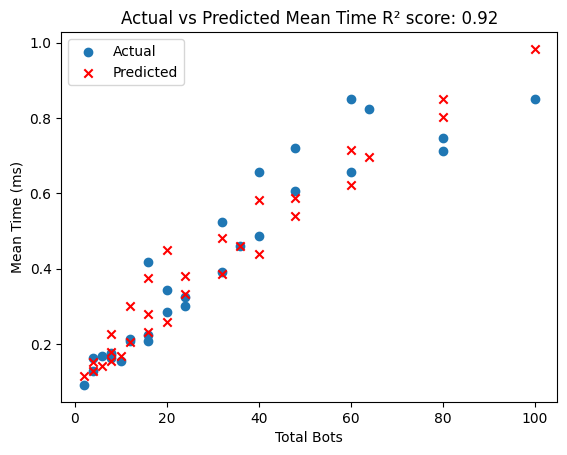

In [52]:
from sklearn.linear_model import LinearRegression

# Prepare the features
X = merged_df[['number_of_servers', 'total_bots']]
y = merged_df['mean']

# Fit the model
model = LinearRegression()
model.fit(X, y)

# Print results
print(f"Intercept: {model.intercept_:.4f}")
print(f"Coefficient for number_of_servers: {model.coef_[0]:.4f}")
print(f"Coefficient for total_bots: {model.coef_[1]:.4f}")
print()

predicted_points = model.predict(merged_df[['number_of_servers', 'total_bots']])
plt.scatter(merged_df['total_bots'], merged_df['mean'], label='Actual')
plt.scatter(merged_df['total_bots'], predicted_points, color='red', label='Predicted', marker='x')
plt.xlabel('Total Bots')
plt.ylabel('Mean Time (ms)')
plt.title(f'Actual vs Predicted Mean Time R² score: {model.score(X, y):.2f}')
plt.savefig('./assets/actual_vs_predicted_mean_time.jpg')
plt.legend()
plt.show()